--------------- QUESTION 1 ----------------
QUESTION 1 (60151, 8)
          ServiceSta...            Address... Suburb... Postcode... Brand... FuelCode...       PriceUpdat...  Price...
0         Shell Croydon  418-424 LIVERPOOL RD   CROYDON        2132    Shell         P98 2025-01-01 02:17:21     205.9
1  Ampol Foodary Coogee  146-148 COOGEE BAY R    COOGEE        2034    Ampol         P98 2025-01-01 02:18:03     211.9
2  Ampol Foodary Coogee  146-148 COOGEE BAY R    COOGEE        2034    Ampol         U91 2025-01-01 02:18:03     187.9
3  Ampol Foodary Coogee  146-148 COOGEE BAY R    COOGEE        2034    Ampol         E10 2025-01-01 02:18:03     185.9
4  Ampol Foodary Coogee  146-148 COOGEE BAY R    COOGEE        2034    Ampol         P95 2025-01-01 02:18:04     203.9
--------------- QUESTION 2 ----------------
QUESTION 2 (59256, 8)
                Name...            Address... Suburb... Postcode... Brand... FuelCode...       PriceUpdat...  Price...
0         Shell Croydon  418-424 LI

<Figure size 1000x600 with 0 Axes>

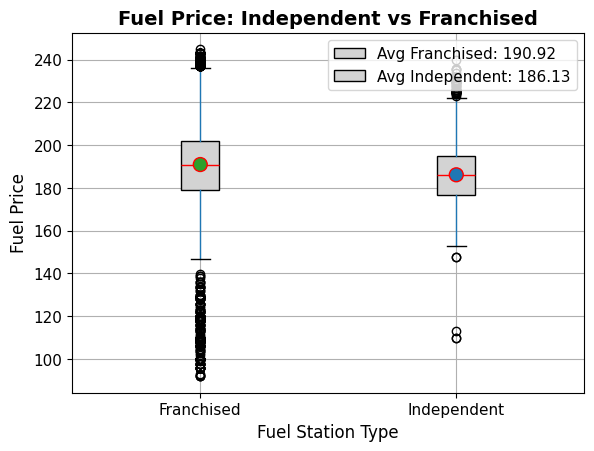

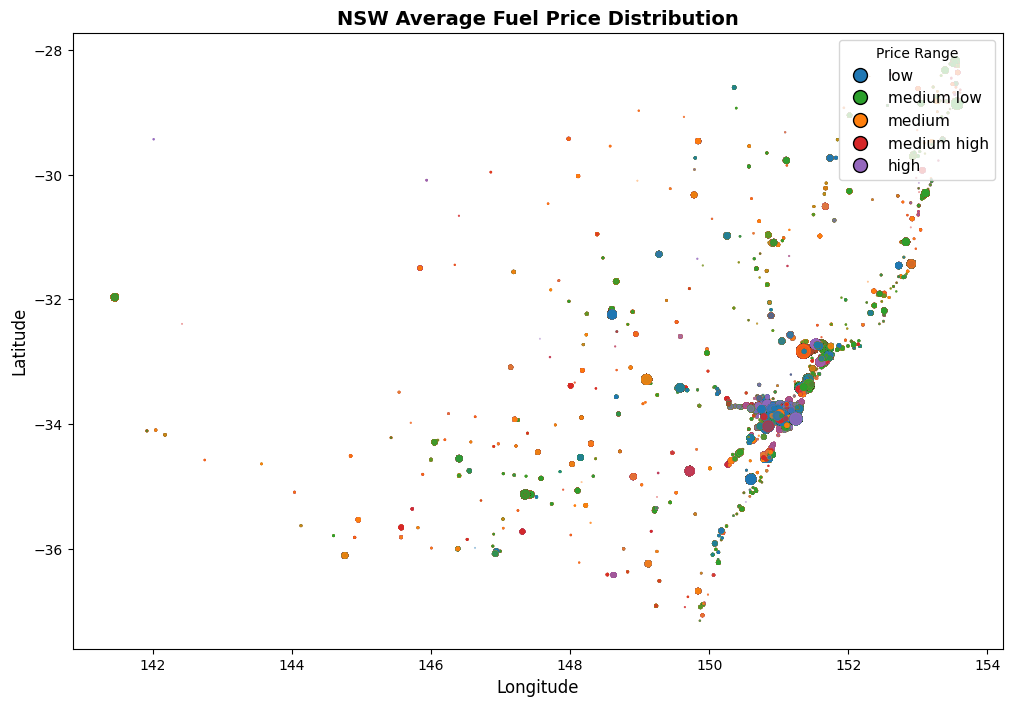

In [2]:
#! usrbinenv python3
# -- coding utf-8 --

# Third-party libraries
# NOTE You may only use the following third-party libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
# NOTE It isn't necessary to use all of these to complete the assignment,
# but you are free to do so, should you choose.

# Standard libraries
# NOTE You may use any of the Python 3.11 or 3.13 standard libraries
# httpsdocs.python.org3.11libraryindex.html
# httpsdocs.python.org3.13libraryindex.html
from pathlib import Path
# ... import your standard libraries here ...


######################################################
# NOTE DO NOT MODIFY THE LINE BELOW ...
######################################################
studentid = "z5467129"



######################################################
# NOTE DO NOT MODIFY THE FUNCTION BELOW ...
######################################################
def log(question, output_df=None, other=None):
    print(f"--------------- {question} ----------------")

    if other is not None:
        print(question, other)
    if output_df is not None:
        df = output_df.head(5).copy(True)
        for c in df.columns:
            df[c] = df[c].apply(lambda a: a[:20] if isinstance(a, str) else a)
        
        df.columns = [a[:10] + "..." for a in df.columns]
        print(df.to_string())



######################################################
# NOTE YOU MAY ADD ANY HELPER FUNCTIONS BELOW ...
######################################################


######################################################
# QUESTIONS TO COMPLETE BELOW ...
######################################################


######################################################
# NOTE DO NOT MODIFY THE FUNCTION SIGNATURE BELOW ...
######################################################
def question_1(fuel_csv):
    ######################################################
    # TODO Your code goes here ...
    ######################################################
    try:
        pd.read_csv(fuel_csv, dtype=str, nrows=50000)
        error_row = None
    except pd.errors.ParserError as e:
        error_row = int(str(e).split("line ")[-1].split(",")[0]) - 1 
        
        Apart = pd.read_csv(fuel_csv, dtype=str, nrows=error_row+1, index_col=False, on_bad_lines="skip")
        error_PLACE = pd.read_csv(fuel_csv, dtype=str, skiprows=error_row, nrows=1, index_col=False, header=None)
        error_PLACE = error_PLACE.iloc[:, 1:]
        error_PLACE.columns = Apart.columns
        Bpart = pd.read_csv(fuel_csv, dtype=str, skiprows=error_row, index_col=False).iloc[:, 1:]
        Bpart.columns = Apart.columns
        df1 = pd.concat([Apart, error_PLACE, Bpart], ignore_index=True)

        df1["PriceUpdatedDate"] = pd.to_datetime(df1["PriceUpdatedDate"], errors="coerce")
        df1["Price"] = pd.to_numeric(df1["Price"], errors="coerce")
    ######################################################
    # NOTE DO NOT MODIFY THE CODE BELOW ...
    ######################################################
    log("QUESTION 1", output_df=df1, other=df1.shape)
    return df1


######################################################
# NOTE DO NOT MODIFY THE FUNCTION SIGNATURE BELOW ...
######################################################
def question_2(df1):
    ######################################################
    # TODO Your code goes here ...
    ######################################################
    df2 = df1.rename(columns={"ServiceStationName": "Name"})
    df2["Suburb"] = df2["Suburb"].str.upper()
    NSW_mask = df2["Address"].str.contains("NSW", na=False)
    New_South_Wales_mask = df2["Address"].str.contains("New South Wales", na=False)
    NEW_SOUTH_WALES_mask = df2["Address"].str.contains("NEW SOUTH WALES", na=False)
    df2 = df2[NSW_mask | New_South_Wales_mask | NEW_SOUTH_WALES_mask]
    ######################################################
    # NOTE DO NOT MODIFY THE CODE BELOW ...
    ######################################################
    log("QUESTION 2", output_df=df2, other=df2.shape)
    return df2


######################################################
# NOTE DO NOT MODIFY THE FUNCTION SIGNATURE BELOW ...
######################################################
def question_3(postcodes_json):
    ######################################################
    # TODO Your code goes here ...
    ######################################################
    df3 = pd.read_json(postcodes_json)
    df3 = df3.drop(columns=["accuracy"])
    ######################################################
    # NOTE DO NOT MODIFY THE CODE BELOW ...
    ######################################################
    log("QUESTION 3", output_df=df3, other=df3.shape)
    return df3


######################################################
# NOTE DO NOT MODIFY THE FUNCTION SIGNATURE BELOW ...
######################################################
def question_4(df2, df3):
    ######################################################
    # TODO Your code goes here ...
    ######################################################
    df2["Postcode"] = df2["Postcode"].astype(str)
    df3["postcode"] = df3["postcode"].astype(str)
    df2["Suburb"] = df2["Suburb"].str.upper()
    df3["place_name"] = df3["place_name"].str.upper()

    df4 = df2.merge(df3, left_on=["Postcode", "Suburb"], right_on=["postcode", "place_name"], how="left")

    df4["Latitude"] = df4["latitude"]
    df4["Longitude"] = df4["longitude"]

    nan_place = df4["Latitude"].isna()
    same_postcode = df3.sort_values("place_name").groupby("postcode").first().reset_index()
    df4.loc[nan_place, "Latitude"] = df4.loc[nan_place, "Postcode"].map(same_postcode.set_index("postcode")["latitude"])
    df4.loc[nan_place, "Longitude"] = df4.loc[nan_place, "Postcode"].map(same_postcode.set_index("postcode")["longitude"])

    df4 = df4[df2.columns.tolist() + ["Latitude", "Longitude"]]

    df4.to_csv("df4.csv", index=False)
    ######################################################
    # NOTE DO NOT MODIFY THE CODE BELOW ...
    ######################################################
    log("QUESTION 4", output_df=df4, other=df4.shape)
    return df4

######################################################
# NOTE DO NOT MODIFY THE FUNCTION SIGNATURE BELOW ...
######################################################
def question_5(df4):
    ######################################################
    # TODO Your code goes here ...
    ######################################################
    df4["PriceDate"] = df4["PriceUpdatedDate"].dt.date
    group_columns = ["Postcode", "FuelCode", "Name", "PriceDate"]
    grouped = df4.groupby(group_columns)
    station_ed_avg = grouped["Price"].mean().reset_index()
    postcode_ed_avg = station_ed_avg.groupby(["Postcode", "FuelCode", "PriceDate"])["Price"].mean().reset_index()
    df5 = postcode_ed_avg.groupby(["Postcode", "FuelCode"])["Price"].mean().reset_index()
    df5 = df5.rename(columns={"FuelCode": "FuelType", "Price": "AveragePrice"})

    fuel_type = df5["FuelType"].unique()
    postcode_type = df5["Postcode"].unique()
    correct_index = pd.MultiIndex.from_product([postcode_type, fuel_type], names=["Postcode", "FuelType"])
    df_missing = pd.DataFrame(list(correct_index), columns=["Postcode", "FuelType"])
    df5 = df5.merge(df_missing, on=["Postcode", "FuelType"], how="right").fillna(0.00)
    df5 = df5.sort_values(["Postcode", "FuelType"]).set_index(["Postcode", "FuelType"])
    df5["AveragePrice"] = df5["AveragePrice"].round(2)
    df5 = df5.sort_index(level=["Postcode", "FuelType"])
    ######################################################
    # NOTE DO NOT MODIFY THE CODE BELOW ...
    ######################################################
    log("QUESTION 5", output_df=df5, other=df5.shape)
    return df5

######################################################
# NOTE DO NOT MODIFY THE FUNCTION SIGNATURE BELOW ...
######################################################
def question_6(df4, df5):
    ######################################################
    # TODO Your code goes here ...
    ######################################################
    df5 = df5.reset_index()
    df6 = df4.merge(df5, how="left", left_on=["Postcode", "FuelCode"], right_on=["Postcode", "FuelType"])
    df6["PriceChangeAverage"] = ((df6["Price"] - df6["AveragePrice"]) / df6["AveragePrice"]) * 100
    df6["PriceChangeAverage"] = df6["PriceChangeAverage"].round(2)
    df6["PriceChangeAverage"] = df6["PriceChangeAverage"].fillna(0.00)
    df6.drop(columns=["FuelType", "AveragePrice"], inplace=True)
    ######################################################
    # NOTE DO NOT MODIFY THE CODE BELOW ...
    ######################################################
    log("QUESTION 6", output_df=df6, other=df6.shape)
    return df6


######################################################
# NOTE DO NOT MODIFY THE FUNCTION SIGNATURE BELOW ...
######################################################
def question_7(df6):
    ######################################################
    # TODO Your code goes here ...
    ######################################################
    df6["PriceUpdatedDate"] = pd.to_datetime(df6["PriceUpdatedDate"], errors="coerce")
    df7 = df6.copy()
    df7 = df7.sort_values(by=["Name", "Address", "FuelCode", "PriceUpdatedDate"])
    df7["Price"] = pd.to_numeric(df7["Price"], errors="coerce")
    df7["PriceChangePrevious"] = 0.00
    grouped = df7.groupby(["Name", "Address", "FuelCode"])
    price_diff = grouped["Price"].transform(lambda x: x.diff())
    df7["PriceChangePrevious"] = price_diff.fillna(0.00)
    df7["PriceChangePrevious"] = df7["PriceChangePrevious"].apply(lambda x: f"{x:.2f}")
    df7["PriceChangePrevious"] = pd.to_numeric(df7["PriceChangePrevious"], errors="coerce")
    ######################################################
    # NOTE DO NOT MODIFY THE CODE BELOW ...
    ######################################################
    log("QUESTION 7", output_df=df7, other=df7.shape)
    return df7


######################################################
# NOTE DO NOT MODIFY THE FUNCTION SIGNATURE BELOW ...
######################################################
def question_8(df7):
    ######################################################
    # TODO Your code goes here ...
    ######################################################
    def Independent_chooson(brand):
        if brand == "Independent":
            return "Independent"
        else:
            return "Franchised"

    df7["Type"] = df7["Brand"].apply(Independent_chooson)
    colors = {"Independent": "#2ca02c", "Franchised": "#1f77b4"}

    plt.figure(figsize=(10, 6))

    df7.boxplot(column="Price", by="Type", patch_artist=True, boxprops=dict(facecolor="lightgray"), medianprops=dict(color="red"))
    plt.title("Fuel Price: Independent vs Franchised", fontsize=14, fontweight="bold")
    plt.suptitle("")
    plt.ylabel("Fuel Price", fontsize=12)
    plt.xlabel("Fuel Station Type", fontsize=12)
    plt.xticks(fontsize=11)
    plt.yticks(fontsize=11)

    avg_prices = df7.groupby("Type")["Price"].mean()
    plt.scatter([1, 2], avg_prices.values, 
            color=[colors["Independent"], colors["Franchised"]], 
            edgecolors="red",  
            s=100, 
            zorder=3)
    
    labels = [f"Avg {t}: {p:.2f}" for t, p in zip(avg_prices.index, avg_prices.values)]
    plt.legend(labels, fontsize=11, loc="upper right")

    answer8 = (
        "We have chosen the box plot for comparing the distribution of fuel prices between independent and chain petrol stations. "
        "It is a very suitable visualisation tool for such comparisons as it effectively shows the Median, Interquartile Range and Outliers of the data to reveal price differences between different types of petrol stations. "
        "Based on this graph, we can see that the average price of fuel is higher for chain petrol stations with a median of around 190.90 cents/litre, while the median for independent petrol stations is lower at around 185.90 cents/litre, indicating that independent petrol stations tend to offer more competitive prices. "
        "Independent petrol filling stations have more stable prices with smaller IQRs, indicating less price volatility. "
        "On the other hand, prices at chain petrol filling stations are more variable, with more stations offering higher prices. "
        "However, it is clear that most of the independent petrol filling stations have high fixed prices, while the chain petrol filling stations may have lower prices due to their geographical location or brand name. "
        "From this we can see that the choice of petrol station may depend on the current situation, but generally speaking, independent petrol stations may be a better choice for long-term use because of their more stable prices. "
        "Chained petrol stations, on the other hand, have a higher brand recognition, but their prices fluctuate greatly, with prices in some areas even far exceeding the average."
    )



    ######################################################
    # NOTE DO NOT MODIFY THE CODE BELOW ...
    ######################################################
    plt.savefig(f"{studentid}-Q8.png")
    log("QUESTION 8", other=answer8)
    return answer8

######################################################
# NOTE DO NOT MODIFY THE FUNCTION SIGNATURE BELOW ...
######################################################
def question_9(df7):
    ######################################################
    # TODO Your code goes here ...
    ######################################################
    Q1, Q2, Q3, Q4 = df7["Price"].quantile([0.2, 0.4, 0.6, 0.8])
    price_level = ["low", "medium low", "medium", "medium high", "high"]
    price_colors = ["#1f77b4", "#2ca02c", "#ff7f0e", "#d62728", "#9467bd"]
    df7["PriceCategory"] = pd.cut(df7["Price"], 
                                  bins=[-float("inf"), Q1, Q2, Q3, Q4, float("inf")], 
                                  labels=price_level)
    df7["Color"] = df7["PriceCategory"].map(dict(zip(price_level, price_colors)))
    df7["Size"] = df7.groupby(["Longitude", "Latitude"])["Price"].transform("count")
    df7["Size"] = df7["Size"] / df7["Size"].max() * 100
    plt.figure(figsize=(12, 8))
    plt.scatter(df7["Longitude"], df7["Latitude"], 
                c=df7["Color"], alpha=0.6, 
                s=df7["Size"])
    legend_elements = [
        plt.Line2D([0], [0], marker='o', color='w', label=label,
                   markersize=10, markerfacecolor=color, markeredgecolor='black')
        for label, color in zip(price_level, price_colors)
    ]

    plt.legend(handles=legend_elements, title="Price Range", fontsize=11, loc="upper right")
    plt.title("NSW Average Fuel Price Distribution", fontsize=14, fontweight="bold")
    plt.xlabel("Longitude", fontsize=12)
    plt.ylabel("Latitude", fontsize=12)

    answer9 = (
        "We used a Geospatial Scatter Plot to analyse the distribution of fuel prices in different parts of NSW. "
        "This plot allows us to see the coastal boundaries, and can be compared to a map to make the picture clearer. "
        "We have categorised fuel prices by five colours (from low (blue) to high (purple)) and the size of the dots represents the number of petrol stations in the location to give a visual representation of the competition in the market. "
        "The geographical distribution of the chart shows that Sydney covers all price ranges, indicating a high degree of price diversity in the region. "
        "This reflects the fact that fuel prices in major cities are influenced by a number of factors, such as market competition, supply chain fluctuations, fuel discounts, and price variations based on geographic location. "
        "In contrast, fuel prices in the interior are generally low or medium and there are few high-priced (purple) petrol stations. "
        "This may be due to the lower density of petrol filling stations in the inland areas, where the market is less competitive and fuel prices are generally more stable. "
        "The lower operating costs of inland PFSs as compared with those in coastal metropolitan areas may also be one of the reasons for the low fuel prices. "
        "Moreover, coastal areas have more fuel transportation and supply centres, and hence fuel prices are more competitive and may be subject to discounts or promotional activities. "
        "However, the higher operating costs in these regions result in some petrol stations maintaining higher prices. "
        "On the other hand, inland areas, where transport costs are higher but market competition is lower, fuel prices are more stable and mostly in the low to medium range."
    )



    ######################################################
    # NOTE DO NOT MODIFY THE CODE BELOW ...
    ######################################################
    plt.savefig(f"{studentid}-Q9.png")
    log("QUESTION 9", other=answer9)
    return answer9


######################################################
# NOTE DO NOT MODIFY THE MAIN FUNCTION BELOW ...
######################################################
if __name__ == "__main__":
    df1 = question_1("fuel.csv")
    df2 = question_2(df1.copy(True))
    df3 = question_3("postcodes.json")
    df4 = question_4(df2.copy(True), df3.copy(True))
    df5 = question_5(df4.copy(True))
    df6 = question_6(df4.copy(True), df5.copy(True))
    df7 = question_7(df6.copy(True))
    answer8 = question_8(df7.copy(True))
    answer9 = question_9(df7.copy(True))

In [3]:
import pandas as pd
import random

def check_df7(df6, df7):
    print("✅ 开始 df7 自检...")

    # 1️⃣ **确保数据类型正确**
    df6["PriceChangeAverage"] = pd.to_numeric(df6["PriceChangeAverage"], errors="coerce")
    df7["PriceChangePrevious"] = pd.to_numeric(df7["PriceChangePrevious"], errors="coerce")
    df6["PriceUpdatedDate"] = pd.to_datetime(df6["PriceUpdatedDate"], errors='coerce')
    df7["PriceUpdatedDate"] = pd.to_datetime(df7["PriceUpdatedDate"], errors='coerce')

    # 确保 Name 和 Address 统一格式，去除空格
    df6["Name"] = df6["Name"].str.strip()
    df6["Address"] = df6["Address"].str.strip()
    df7["Name"] = df7["Name"].str.strip()
    df7["Address"] = df7["Address"].str.strip()

    # 2️⃣ **检查 df7 结构是否正确**
    column_added_score = 0.25 if "PriceChangePrevious" in df7.columns else 0
    print(f"✓ PriceChangePrevious 列已正确添加" if column_added_score else "✗ PriceChangePrevious 列未添加")

    expected_shape = (59256, 12)
    shape_score = 0.25 if df7.shape == expected_shape else 0
    print(f"✓ df7 形状正确: {df7.shape}" if shape_score else f"✗ df7 形状错误，期望: {expected_shape}，实际: {df7.shape}")

    # 3️⃣ **找到所有有效的 (Name, Address, FuelType) 组合**
    fuel_col = "FuelType" if "FuelType" in df6.columns else "FuelCode"

    station_fuel_combinations = (
        df6.groupby(["Name", "Address", fuel_col])
        .size()
        .reset_index()[["Name", "Address", fuel_col]]
    )

    valid_combinations = [
        (row["Name"], row["Address"], row[fuel_col])
        for _, row in station_fuel_combinations.iterrows()
        if len(df6[(df6["Name"] == row["Name"]) & (df6["Address"] == row["Address"]) & (df6[fuel_col] == row[fuel_col])]) > 1
    ]

    # 4️⃣ **进行随机抽样检查**
    sample_size = min(15, len(valid_combinations))
    if sample_size == 0:
        print("⚠️ 没有找到多个时间戳的服务站和燃油类型组合")
        return 0

    sample_combinations = random.sample(valid_combinations, sample_size)

    correct_calculations, correct_format, first_row_correct = 0, 0, 0
    print("\n🎯 随机抽样检查 `PriceChangePrevious` 计算:")

    for i, (name, address, fuel) in enumerate(sample_combinations, 1):
        group = df6[
            (df6["Name"] == name) & 
            (df6["Address"] == address) & 
            (df6[fuel_col] == fuel)
        ].sort_values("PriceUpdatedDate")

        if len(group) > 1:
            random_idx = random.randint(1, len(group) - 1)
            current_row, previous_row = group.iloc[random_idx], group.iloc[random_idx - 1]

            expected_price_diff = round(current_row["Price"] - previous_row["Price"], 2)

            df7_row = df7[
                (df7["Name"] == name) & 
                (df7["Address"] == address) & 
                (df7[fuel_col] == fuel) & 
                (df7["PriceUpdatedDate"] == current_row["PriceUpdatedDate"])
            ]

            if not df7_row.empty:
                actual_price_diff = float(df7_row["PriceChangePrevious"].values[0])
                
                actual_str = f"{actual_price_diff:.2f}"
                expected_format = f"{float(actual_price_diff):.2f}"  # 期望格式

                calculation_correct = abs(actual_price_diff - expected_price_diff) < 0.01
                format_correct = actual_str == expected_format  # **检查是否完全匹配**

                if calculation_correct:
                    correct_calculations += 1
                if format_correct:
                    correct_format += 1

                print(f"  ✅ 样本 {i}: {name}, {address}, {fuel}")
                print(f"     当前价格={current_row['Price']:.2f}, 前一价格={previous_row['Price']:.2f}")
                print(f"     预期 PriceChangePrevious={expected_price_diff:.2f}, 实际={actual_price_diff:.2f}")
                print(f"     计算 {'✓' if calculation_correct else '✗'}, 格式 {'✓' if format_correct else '✗'}")
            else:
                print(f"  ❌ 样本 {i}: 无法在 df7 中找到对应记录")

        # **检查第一行 `PriceChangePrevious` 是否为 `0.00`**
        first_row = group.iloc[0]
        df7_first_row = df7[
            (df7["Name"] == name) & 
            (df7["Address"] == address) & 
            (df7[fuel_col] == fuel) & 
            (df7["PriceUpdatedDate"] == first_row["PriceUpdatedDate"])
        ]

        if not df7_first_row.empty:
            first_row_value = float(df7_first_row["PriceChangePrevious"].values[0])
            if first_row_value == 0:
                first_row_correct += 1
                print(f"  ✅ 第一行检查: {name}, {address}, {fuel} 的第一行值为 0 ✓")
            else:
                print(f"  ❌ 第一行检查: {name}, {address}, {fuel} 的第一行值为 {first_row_value}，应为 0 ✗")

    # 5️⃣ **计算评分**
    calculation_accuracy = correct_calculations / sample_size
    format_accuracy = correct_format / sample_size
    first_row_accuracy = first_row_correct / sample_size

    print(f"\n✅ 计算准确率: {correct_calculations}/{sample_size} = {calculation_accuracy:.2%}")
    print(f"✅ 格式准确率: {correct_format}/{sample_size} = {format_accuracy:.2%}")
    print(f"✅ 第一行正确率: {first_row_correct}/{sample_size} = {first_row_accuracy:.2%}")

    calculation_score = 0.25 if calculation_accuracy >= 0.9 else 0
    format_score = 0.25 if format_accuracy >= 0.9 else 0

    total_score = column_added_score + shape_score + calculation_score + format_score
    print(f"\n🏆 总分: {total_score}/1.0")

    return total_score


# 运行优化后的自检函数
total_score = check_df7(df6, df7)


✅ 开始 df7 自检...
✓ PriceChangePrevious 列已正确添加
✓ df7 形状正确: (59256, 12)

🎯 随机抽样检查 `PriceChangePrevious` 计算:
  ✅ 样本 1: Coles Express Lansvale West, 240 Hume Highway, LANSVALE NSW 2166, P95
     当前价格=233.90, 前一价格=193.90
     预期 PriceChangePrevious=40.00, 实际=40.00
     计算 ✓, 格式 ✓
  ✅ 第一行检查: Coles Express Lansvale West, 240 Hume Highway, LANSVALE NSW 2166, P95 的第一行值为 0 ✓
  ✅ 样本 2: PEARL ENERGY THORNTON, 5 GLENWOOD DR, THORNTON NSW 2322, U91
     当前价格=163.90, 前一价格=164.90
     预期 PriceChangePrevious=-1.00, 实际=-1.00
     计算 ✓, 格式 ✓
  ✅ 第一行检查: PEARL ENERGY THORNTON, 5 GLENWOOD DR, THORNTON NSW 2322, U91 的第一行值为 0 ✓
  ✅ 样本 3: Shell Reddy Express Dubbo, 131-133 Cobra St (Cnr Fitzroy St), Dubbo NSW 2830, P98
     当前价格=204.90, 前一价格=202.90
     预期 PriceChangePrevious=2.00, 实际=2.00
     计算 ✓, 格式 ✓
  ✅ 第一行检查: Shell Reddy Express Dubbo, 131-133 Cobra St (Cnr Fitzroy St), Dubbo NSW 2830, P98 的第一行值为 0 ✓
  ✅ 样本 4: ENHANCE TERALBA, 63 York St, Teralba NSW 2284, DL
     当前价格=186.90, 前一价格=199.90
     预期 PriceCha